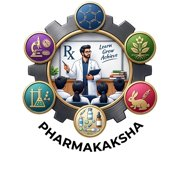

# BP301T · Unit II — Regression Models in Healthcare
**Pharmakaksha · Learn · Grow · Achieve**
*Introduction to Machine Learning in Pharmaceutical Sciences · B.Pharm Semester III · PCI NEP 2020*

This notebook contains every example and demo from the Unit II study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit2_Regression_Models.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit2_Regression_Models.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data (except scikit-learn's built-in breast-cancer dataset). The models are for learning machine learning only. They are not clinical tools.

## 2.1 What is regression?
**Regression** predicts a **continuous number**: a fall in blood pressure, % drug dissolved, clearance in L/h. Simple linear regression fits a straight line, *y = b₀ + b₁x*, by **least squares**: it chooses the line that makes the sum of squared errors as small as possible.

## 2.2 Simple linear regression: dose–response
`dose_response.csv` holds 24 fictional readings: the fall in systolic blood pressure (mmHg) at eight doses of an antihypertensive, three patients per dose.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

dr = load("dose_response.csv")
print(dr.head())

X = dr[["dose_mg"]]
y = dr["sbp_fall_mmHg"]
model = LinearRegression().fit(X, y)
b0, b1 = model.intercept_, model.coef_[0]
print(f"Intercept b0 = {b0:.2f} mmHg,  slope b1 = {b1:.3f} mmHg per mg")
print("Predicted fall at 22 mg:", round(model.predict(pd.DataFrame({"dose_mg": [22]}))[0], 1), "mmHg")

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(dr["dose_mg"], dr["sbp_fall_mmHg"], color="#17725C", s=50, label="Patients")
xs = pd.DataFrame({"dose_mg": np.linspace(0, 45, 50)})
plt.plot(xs["dose_mg"], model.predict(xs), color="#E07A2E", linewidth=2.5,
         label=f"y = {b0:.2f} + {b1:.3f}x")
plt.xlabel("Dose (mg)")
plt.ylabel("Fall in systolic BP (mmHg)")
plt.title("Dose–response: simple linear regression")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 2.3 Residuals and goodness of fit
A **residual** is *actual − predicted*. Good residuals scatter randomly around zero with no pattern.

In [ ]:
dr["predicted"] = model.predict(X).round(2)
dr["residual"] = (dr["sbp_fall_mmHg"] - dr["predicted"]).round(2)
print(dr.head(6))
print("Sum of residuals:", round(dr["residual"].sum(), 6))   # least squares makes this ≈ 0

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(dr["predicted"], dr["residual"], color="#12303A", s=45)
plt.axhline(0, color="#E07A2E", linestyle="--")
plt.xlabel("Predicted fall (mmHg)")
plt.ylabel("Residual (mmHg)")
plt.title("Residual plot: random scatter around zero = good fit")
plt.grid(alpha=0.3); plt.show()

## 2.4 MSE, RMSE and R²
- **MSE** = mean of squared residuals (units²) · **RMSE** = √MSE (same units as *y*) · **R²** = 1 − SS_res/SS_tot = share of the variation explained (0 to 1).

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

res = dr["residual"]
mse = np.mean(res ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum(res ** 2) / np.sum((y - y.mean()) ** 2)
print(f"By hand:  MSE = {mse:.2f}  RMSE = {rmse:.2f} mmHg  R² = {r2:.3f}")

pred = model.predict(X)
print(f"sklearn:  MSE = {mean_squared_error(y, pred):.2f}  RMSE = {np.sqrt(mean_squared_error(y, pred)):.2f} mmHg  R² = {r2_score(y, pred):.3f}")

## 2.5 Multiple linear regression: predicting dissolution
`dissolution_batches.csv` holds 40 fictional tablet batches: four formulation and process variables, and the % drug dissolved at 30 minutes.

In [ ]:
from sklearn.model_selection import train_test_split

dis = load("dissolution_batches.csv")
print(dis.describe().round(1))

features = ["binder_pct", "disintegrant_pct", "compression_kN", "lubricant_pct"]
X = dis[features]
y = dis["dissolved_30min_pct"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

mlr = LinearRegression().fit(X_train, y_train)
coefs = pd.Series(mlr.coef_, index=features).round(2)
print("\nIntercept:", round(mlr.intercept_, 2))
print(coefs)

In [ ]:
pred = mlr.predict(X_test)
print(f"Test RMSE = {np.sqrt(mean_squared_error(y_test, pred)):.2f} %   Test R² = {r2_score(y_test, pred):.3f}")

new_batch = pd.DataFrame({"binder_pct": [3.0], "disintegrant_pct": [6.0],
                          "compression_kN": [12.0], "lubricant_pct": [1.0]})
print("Predicted dissolution for the new batch:", round(mlr.predict(new_batch)[0], 1), "%")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, color="#E07A2E", s=60)
plt.plot([55, 95], [55, 95], color="#12303A", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual dissolved at 30 min (%)")
plt.ylabel("Predicted (%)")
plt.title("Predicted vs actual (test batches)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 2.6 PK parameter estimation
**(a) Elimination rate from a concentration–time profile.** After an IV bolus, ln C falls in a straight line: ln C = ln C₀ − kₑ·t. A linear regression of ln C on *t* gives kₑ (minus the slope) and C₀ (e to the intercept).

In [ ]:
t = np.array([0.5, 1, 2, 3, 4, 6, 8, 10, 12])                  # h
conc = np.array([11.6, 10.3, 8.9, 7.3, 6.4, 4.3, 3.2, 2.15, 1.6])  # mg/L after 500 mg IV

pkfit = LinearRegression().fit(t.reshape(-1, 1), np.log(conc))
ke = -pkfit.coef_[0]
c0 = np.exp(pkfit.intercept_)
dose = 500
V = dose / c0
print(f"ke = {ke:.3f} 1/h   t½ = {0.693 / ke:.2f} h   C0 = {c0:.2f} mg/L")
print(f"V = {V:.1f} L   CL = {ke * V:.2f} L/h   AUC(0–∞) = {c0 / ke:.1f} mg·h/L")
print("R² of the log-linear fit:", round(pkfit.score(t.reshape(-1, 1), np.log(conc)), 4))

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(t, conc, color="#12303A", s=50, label="Measured")
tt = np.linspace(0, 12, 100)
plt.plot(tt, c0 * np.exp(-ke * tt), color="#E07A2E", linewidth=2.5, label=f"Fitted: kₑ = {ke:.3f} h⁻¹")
plt.yscale("log")
plt.xlabel("Time (h)")
plt.ylabel("Plasma concentration (mg/L, log scale)")
plt.title("Estimating kₑ by regression of ln C on time")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

**(b) Predicting clearance from patient covariates.** `pk_clearance.csv` (60 fictional patients) relates a renally cleared drug's clearance to creatinine clearance and body weight.

In [ ]:
pk = load("pk_clearance.csv")
Xp = pk[["crcl_ml_min", "weight_kg"]]
yp = pk["clearance_L_h"]
Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.25, random_state=42)

clm = LinearRegression().fit(Xp_train, yp_train)
print("Intercept:", round(clm.intercept_, 3))
print(pd.Series(clm.coef_, index=Xp.columns).round(4))
pp = clm.predict(Xp_test)
print(f"Test RMSE = {np.sqrt(mean_squared_error(yp_test, pp)):.2f} L/h   R² = {r2_score(yp_test, pp):.3f}")

## Worked example: dosing a renally impaired patient
A 60 kg patient has CrCl 30 mL/min. The target average steady-state concentration is 10 mg/L. Maintenance dose rate = CL × Css.

In [ ]:
patient = pd.DataFrame({"crcl_ml_min": [30, 90], "weight_kg": [60, 60]})
cl_pred = clm.predict(patient)
for crcl, cl in zip(patient["crcl_ml_min"], cl_pred):
    print(f"CrCl {crcl:>3} mL/min → CL = {cl:.2f} L/h → dose rate = {cl * 10:.1f} mg/h = {cl * 10 * 24:.0f} mg/day")

## Quick check
A model has R² = 0.95 on training data. Does that prove it will predict new batches well? Decide, then run the cell.

In [ ]:
print("No. Check RMSE and R² on a held-out test set, and look at the residuals.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Fit the dose–response line again and predict the fall in SBP at 30 mg and 50 mg. Why is the 50 mg prediction risky?

**2.** Fit the dissolution model with only `disintegrant_pct`. Compare its test R² with the four-variable model.

**3.** Compute MAE (mean absolute error) for the dissolution test set with `mean_absolute_error`.

**4.** Repeat 2.6(a) using only the first five time points. How much does kₑ change?

---
## Solutions

In [ ]:
# 1
print(model.predict(pd.DataFrame({"dose_mg": [30, 50]})).round(1))
# 50 mg is outside the studied range (5–40 mg): extrapolation; the response may plateau.

In [ ]:
# 2
one = LinearRegression().fit(X_train[["disintegrant_pct"]], y_train)
print(round(r2_score(y_test, one.predict(X_test[["disintegrant_pct"]])), 3), "vs", round(r2_score(y_test, mlr.predict(X_test)), 3))

In [ ]:
# 3
from sklearn.metrics import mean_absolute_error
print(round(mean_absolute_error(y_test, mlr.predict(X_test)), 2), "%")

In [ ]:
# 4
f5 = LinearRegression().fit(t[:5].reshape(-1, 1), np.log(conc[:5]))
print(round(-f5.coef_[0], 3), "1/h vs", round(ke, 3))

---
**Next:** Unit III — Classification Models in Clinical Applications. Pharmakaksha · Learn · Grow · Achieve